# Commanded 10 m/s, ground speed climbs — where is the bug?

**The observation** (from CDaRR experiments): a drone is commanded to a fixed
speed, flies straight and level at 100 m, and its *ground speed keeps
increasing*.

This notebook reproduces the behaviour on the CDaRR BlueSky fork and isolates
the mechanism. Straight flight, no intruder, no CD&R throughout:

1. **Command 10 m/s CAS once** and watch ground speed vs CAS for 30 s.
2. **The existing command form, where the bug lives** — re-command the speed
   each second the way CDaRR's loop does (a ground-frame number stacked
   straight through `SPD`) — compared, in the same plot, against the
   **boundary-converted form** BlueSkyCDaRR now uses.

Run top to bottom with the project venv
(`.venv/bin/python -m ipykernel ...` / *Restart & Run All*). BlueSky is a
process-global singleton, so a fresh kernel gives a fresh sim.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import bluesky as bs
from bluesky.tools.aero import kts, vtas2cas, vcas2tas

bs.init(mode='sim', detached=True)
DT = 0.05
bs.stack.stack(f'DT {DT}')

ALT_M = 100.0
CAS_CMD = 10.0          # m/s — the commanded speed
T_END = 30.0

def fly(recommand_each_second: bool, convert_at_boundary: bool = False):
    """One M600, straight and level; returns (t, gs, cas) histories.

    ``recommand_each_second`` replays the CD&R-loop pattern: once per second,
    read the aircraft's ground speed and command it back through ``SPD``.
    ``convert_at_boundary`` is the fix: convert that ground speed to CAS
    (``vtas2cas``) before stacking, as cdarr/engine.py now does.
    """
    bs.traf.reset()
    bs.traf.cre(acid='DRO', actype='M600', aclat=52.3, aclon=4.7,
                achdg=0.0, acalt=ALT_M, acspd=CAS_CMD)
    bs.stack.stack(f'SPD DRO {CAS_CMD / kts:.6f}')   # SPD takes knots (CAS)
    t_hist, gs_hist, cas_hist = [], [], []
    t, next_cmd = 0.0, 1.0
    for _ in range(int(T_END / DT) + 1):
        if recommand_each_second and t + 1e-9 >= next_cmd:
            spd_ms = float(bs.traf.gs[0])            # a GROUND-frame reading
            if convert_at_boundary:
                spd_ms = float(vtas2cas(spd_ms, ALT_M))
            bs.stack.stack(f'SPD DRO {spd_ms / kts:.6f}')
            next_cmd += 1.0
        t_hist.append(t)
        gs_hist.append(float(bs.traf.gs[0]))
        cas_hist.append(float(bs.traf.cas[0]))
        bs.sim.step()
        t += DT
    return map(np.array, (t_hist, gs_hist, cas_hist))

Reading config from /Users/mfrahman/bluesky/settings.cfg
Using compiled geo functions
Reading magnetic variation data
Loading global navigation database...
Reading cache: /Users/mfrahman/bluesky/cache/navdata.p


Successfully loaded OpenAP performance model
Failed to load BADA performance model
Successfully loaded legacy performance model


Successfully loaded plugin AREA
Successfully loaded plugin DATAFEED


## Experiment 1 — one CAS command, straight and level

Exactly the reported setup: `SPD 10 m/s` once, 30 s, ground speed and CAS on
the same axes.

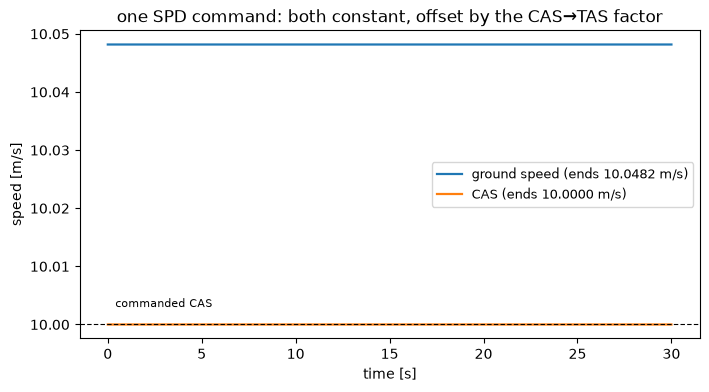

gs drift over 30 s : +0.000000 m/s
gs / cas           : 1.00482
cas2tas @ 100 m ISA : 1.00482


In [2]:
t, gs, cas = fly(recommand_each_second=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t, gs, label=f'ground speed (ends {gs[-1]:.4f} m/s)', lw=1.6)
ax.plot(t, cas, label=f'CAS (ends {cas[-1]:.4f} m/s)', lw=1.6)
ax.axhline(CAS_CMD, color='k', lw=0.8, dashes=(4, 2))
ax.text(0.4, CAS_CMD + 0.003, 'commanded CAS', fontsize=8)
ax.set_xlabel('time [s]')
ax.set_ylabel('speed [m/s]')
ax.set_title('one SPD command: both constant, offset by the CAS\u2192TAS factor')
ax.legend(loc='center right', fontsize=9)
plt.show()

print(f'gs drift over 30 s : {gs[-1] - gs[0]:+.6f} m/s')
print(f'gs / cas           : {gs[-1] / cas[-1]:.5f}')
print(f'cas2tas @ {ALT_M:.0f} m ISA : {float(vcas2tas(CAS_CMD, ALT_M)) / CAS_CMD:.5f}')

**Reading:** with a single command the drone is perfectly stable — no drift at
all. But the ground speed is **10.048 m/s, not 10**: every speed BlueSky
accepts (`cre`'s `acspd`, `creconfs`'s `spd`, the `SPD` stack command) is
**calibrated airspeed**, and the autopilot converts it to true airspeed at the
flight altitude, `TAS = CAS · √(ρ₀/ρ)`. At 100 m ISA that factor is ≈ 1.0048,
and in still air ground speed equals TAS. Harmless — once.

## Experiment 2 — the existing command form vs the boundary-converted form

The **existing form** is CDaRR's (and this package's, before the fix): the
loop works in the ground frame — resolution speeds come from
`gseast`/`gsnorth`, holds re-command the measured ground speed — and stacks
that number straight through `SPD`, e.g. CDaRR's
`bs.stack.stack(f"SPD {id}, {reso_spd/kts}")`. Distilled to its essence:
once per second, command `SPD := measured ground speed`.

The **converted form** is identical except the boundary converts that ground
speed to CAS (`vtas2cas`) before stacking — what `cdarr/engine.py`
does now. Same aircraft, same cadence, same plot:

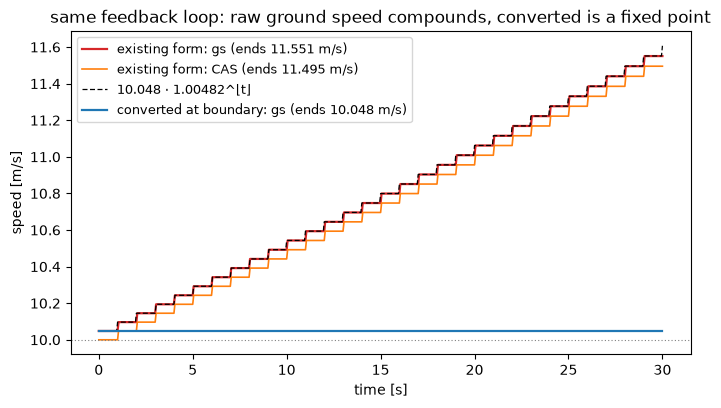

existing form  : x1.1495 over 30 s (1.00482^29 = 1.1496)
converted form : x1.0000 over 30 s
per-command step, existing form: +0.48% of current speed


In [3]:
t2, gs_bug, cas_bug = fly(recommand_each_second=True, convert_at_boundary=False)
t3, gs_fix, cas_fix = fly(recommand_each_second=True, convert_at_boundary=True)

factor = float(vcas2tas(1.0, ALT_M))        # CAS→TAS multiplier at 100 m
analytic = gs_bug[0] * factor ** np.floor(t2)  # one multiplication per re-command

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(t2, gs_bug, color='C3', lw=1.6,
        label=f'existing form: gs (ends {gs_bug[-1]:.3f} m/s)')
ax.plot(t2, cas_bug, color='C1', lw=1.2,
        label=f'existing form: CAS (ends {cas_bug[-1]:.3f} m/s)')
ax.plot(t2, analytic, 'k', lw=0.9, dashes=(4, 2),
        label=f'{gs_bug[0]:.3f} · {factor:.5f}^⌊t⌋')
ax.plot(t3, gs_fix, color='C0', lw=1.6,
        label=f'converted at boundary: gs (ends {gs_fix[-1]:.3f} m/s)')
ax.axhline(CAS_CMD, color='0.5', lw=0.8, dashes=(1, 2))
ax.set_xlabel('time [s]')
ax.set_ylabel('speed [m/s]')
ax.set_title('same feedback loop: raw ground speed compounds, converted is a fixed point')
ax.legend(loc='upper left', fontsize=9)
plt.show()

print(f'existing form  : x{gs_bug[-1] / gs_bug[0]:.4f} over 30 s '
      f'({factor:.5f}^29 = {factor**29:.4f})')
print(f'converted form : x{gs_fix[-1] / gs_fix[0]:.4f} over 30 s')
print(f'per-command step, existing form: +{(factor - 1) * 100:.2f}% of current speed')

**There is the observed behaviour, and its absence, side by side.** Under the
existing form the ground speed ratchets up ~0.48% per re-command, ×1.15 over
30 s, unbounded in longer flights (it only stops at the airframe's envelope):

$$\mathrm{GS}_{k+1} = \mathrm{TAS}_{k+1} = \mathrm{CAS}_{k+1}\cdot
\sqrt{\rho_0/\rho} = \mathrm{GS}_k\cdot\sqrt{\rho_0/\rho},$$

because the loop assigns $\mathrm{CAS}_{k+1} := \mathrm{GS}_k$ — a frame
mismatch at the command boundary, not an integrator bug (Experiment 1 is
perfectly stable). With the boundary conversion the same loop assigns
$\mathrm{CAS}_{k+1} := \mathrm{tas2cas}(\mathrm{GS}_k)$, the multiplication
cancels, and the measured speed is a **fixed point**: the blue line is flat.

## Consequences for this repository

- **CDaRR inherited both halves**: spawn speeds ran 0.48% fast (`acspd` is
  CAS), and aircraft crept faster with every resolution re-command while in
  `resopairs`.
- **BlueSkyCDaRR converts at the boundary** (`engine.py`, ADR 0001 update):
  creation and `SPD` commands convert the package's ground-frame speeds to CAS
  via `vtas2cas`, so a commanded 10 m/s is flown at 10.000 m/s ground — and
  the resolver's ground-frame outputs cannot compound. Locked by
  `test_commanded_ground_speed_is_the_ground_speed_flown`.

The cell below is that check, live:

In [4]:
from cdarr.config import Config
from cdarr.aircraft import MULTIROTOR
from cdarr.engine import PairwiseWorld
from cdarr.scenario import PairwiseEncounter

scenario = PairwiseEncounter(pairs=(1, 1), speed=10.0, tlos=45.0)
geometry = scenario.draw_geometry(np.random.default_rng(0))
config = Config()
with PairwiseWorld(scenario, geometry, MULTIROTOR, config.conflict,
                   config.simulation) as world:
    for _ in range(int(5.0 / config.simulation.dt)):
        world.step()
    flown = world.truth().gs
print('commanded ground speed : 10.000 m/s')
print(f'flown ground speeds    : {np.round(flown, 4)}')

commanded ground speed : 10.000 m/s
flown ground speeds    : [10. 10.]
